# Comparative EDA: City vs Highway vs Combined

This notebook produces side-by-side visualizations for three dataset slices:
- **City only** (SJPD, 152,672 records)
- **Highway only** (CHP/SWITRS, 116,541 records)
- **Combined** (269,213 records)

Figures are saved to `reports/figures/comparative/` and do not overwrite existing figures in `reports/figures/`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import chi2_contingency
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

PROJECT_ROOT = Path('..').resolve()
DATA_FILE    = PROJECT_ROOT / 'data' / 'processed' / 'merged_crash_vehicle_data_with_highways.csv'
FIG_DIR      = PROJECT_ROOT / 'reports' / 'figures' / 'comparative'
FIG_DIR.mkdir(parents=True, exist_ok=True)

DATASETS = ['City Only', 'Highway Only', 'Combined']
COLORS   = ['#2196F3', '#FF5722', '#4CAF50']  # blue, orange, green

SEV_LABELS = {0: 'No Injury', 1: 'Minor', 2: 'Moderate', 3: 'Severe', 4: 'Fatal'}
SEV_COLORS = ['#66BB6A', '#FFA726', '#EF5350', '#B71C1C', '#212121']

def save_fig(name):
    path = FIG_DIR / f'{name}.png'
    plt.savefig(path, bbox_inches='tight', dpi=150)
    plt.show()
    print(f'Saved: {path.name}')

## Load Data & Split into 3 Views

In [2]:
print(f'Loading {DATA_FILE.name}...')
df_all = pd.read_csv(DATA_FILE, low_memory=False)
df_all['CrashDateTime'] = pd.to_datetime(df_all['CrashDateTime'], errors='coerce')

df_city    = df_all[df_all['data_source'] == 'SJPD'].copy()
df_highway = df_all[df_all['data_source'] == 'CHP_Highway'].copy()
df_combined = df_all.copy()

dfs = [df_city, df_highway, df_combined]

for name, df in zip(DATASETS, dfs):
    print(f'{name}: {len(df):,} records')

Loading merged_crash_vehicle_data_with_highways.csv...


City Only: 152,672 records
Highway Only: 116,541 records
Combined: 269,213 records


## Data Quality Notes

> **Highway severity limitation**: For CHP_Highway records, `injury_severity` is derived from crash-level counts only — `4` (Fatal) if `NumberKilled > 0`, otherwise `0` (No Injury). The SWITRS parties table does not include per-party injury codes in this dataset, so minor/moderate/severe granularity is unavailable for highway records. This limitation should be noted in the technical report and considered when interpreting severity distributions for the highway-only slice.

> **Deduplication caveat**: 59 SJPD records were removed as likely duplicates of SWITRS records, matched on crash date + lat/lon rounded to ~111 m precision (no time component). A small number of false positives or missed duplicates may remain.

## 1. Injury Severity Distribution

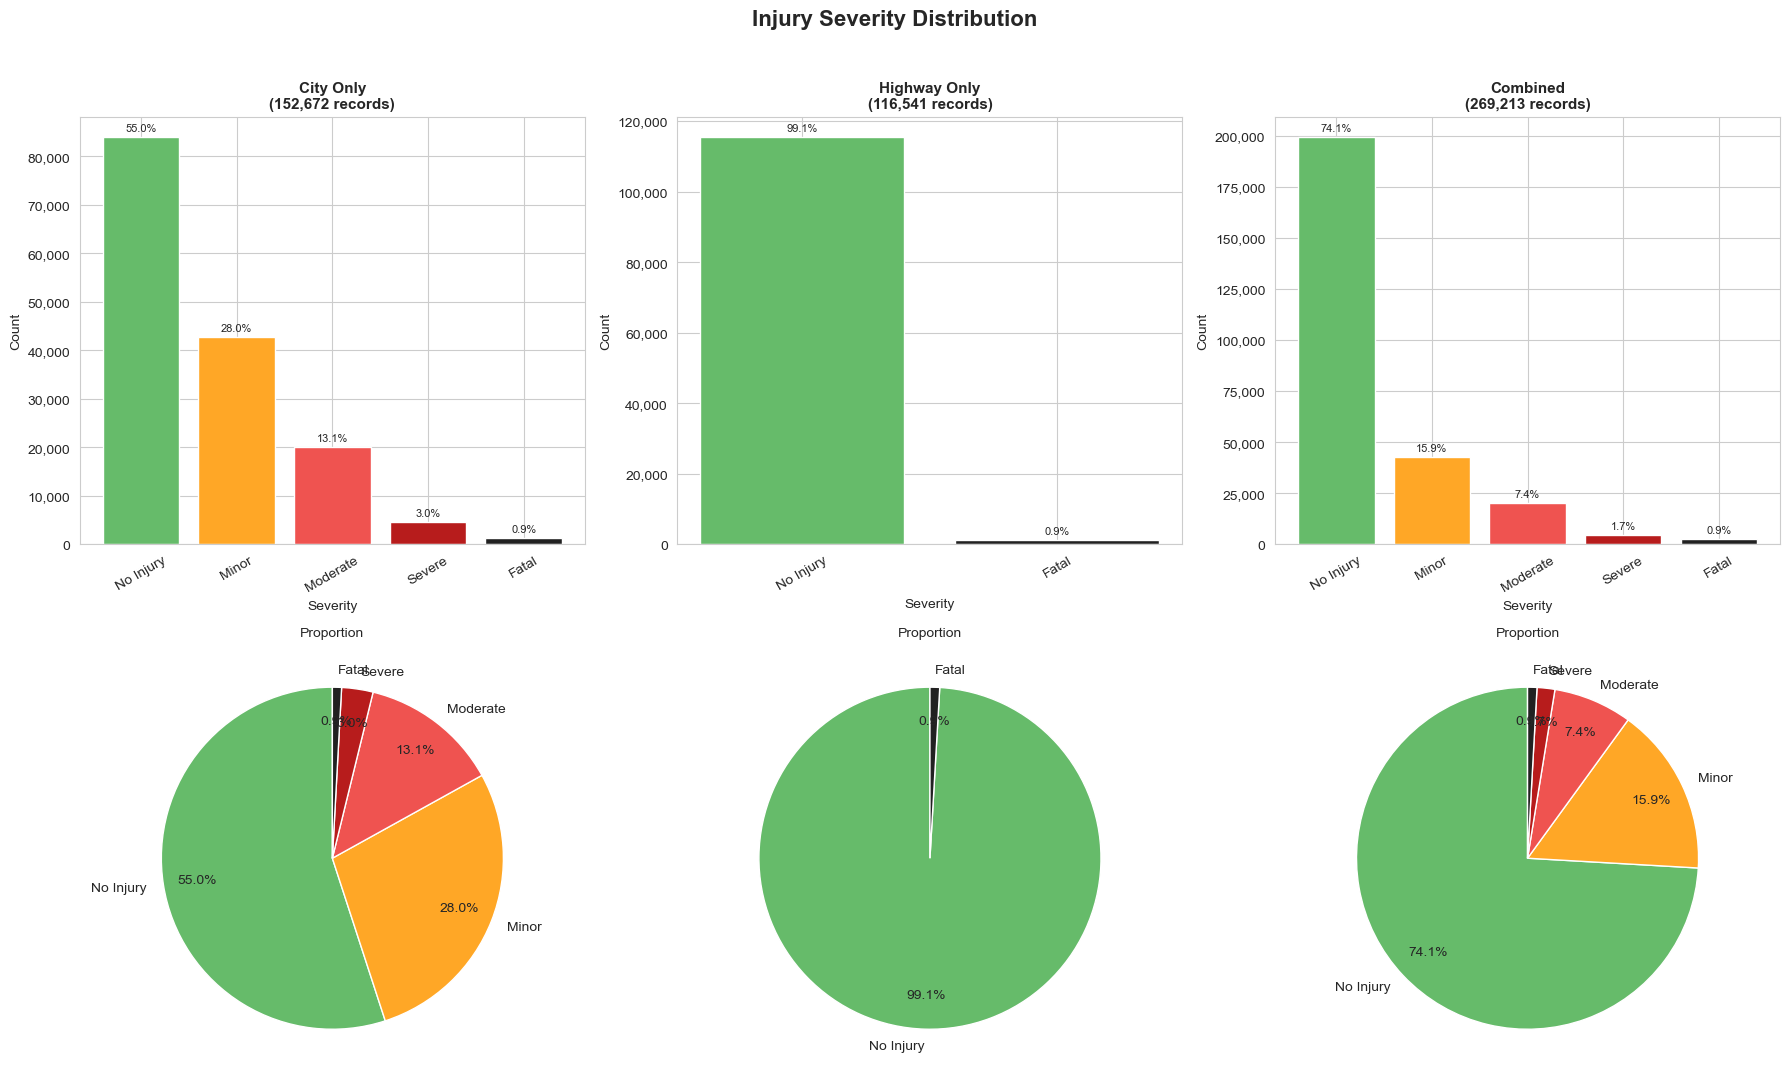

Saved: target_distribution.png


In [3]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Injury Severity Distribution', fontsize=16, fontweight='bold')

for col, (name, df) in enumerate(zip(DATASETS, dfs)):
    counts = df['injury_severity'].value_counts().sort_index()
    labels = [SEV_LABELS.get(int(k), str(k)) for k in counts.index]
    colors = [SEV_COLORS[int(k)] for k in counts.index]

    ax_bar = axes[0, col]
    bars = ax_bar.bar(labels, counts.values, color=colors, edgecolor='white')
    ax_bar.set_title(f'{name}\n({len(df):,} records)', fontsize=11, fontweight='bold')
    ax_bar.set_xlabel('Severity')
    ax_bar.set_ylabel('Count')
    ax_bar.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax_bar.tick_params(axis='x', rotation=30)
    for bar, val in zip(bars, counts.values):
        ax_bar.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(counts)*0.01,
                    f'{val/len(df)*100:.1f}%', ha='center', va='bottom', fontsize=8)

    ax_pie = axes[1, col]
    ax_pie.pie(counts.values, labels=labels, colors=colors,
               autopct='%1.1f%%', startangle=90, pctdistance=0.8)
    ax_pie.set_title('Proportion', fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.96])
save_fig('target_distribution')

## 2. Temporal Patterns

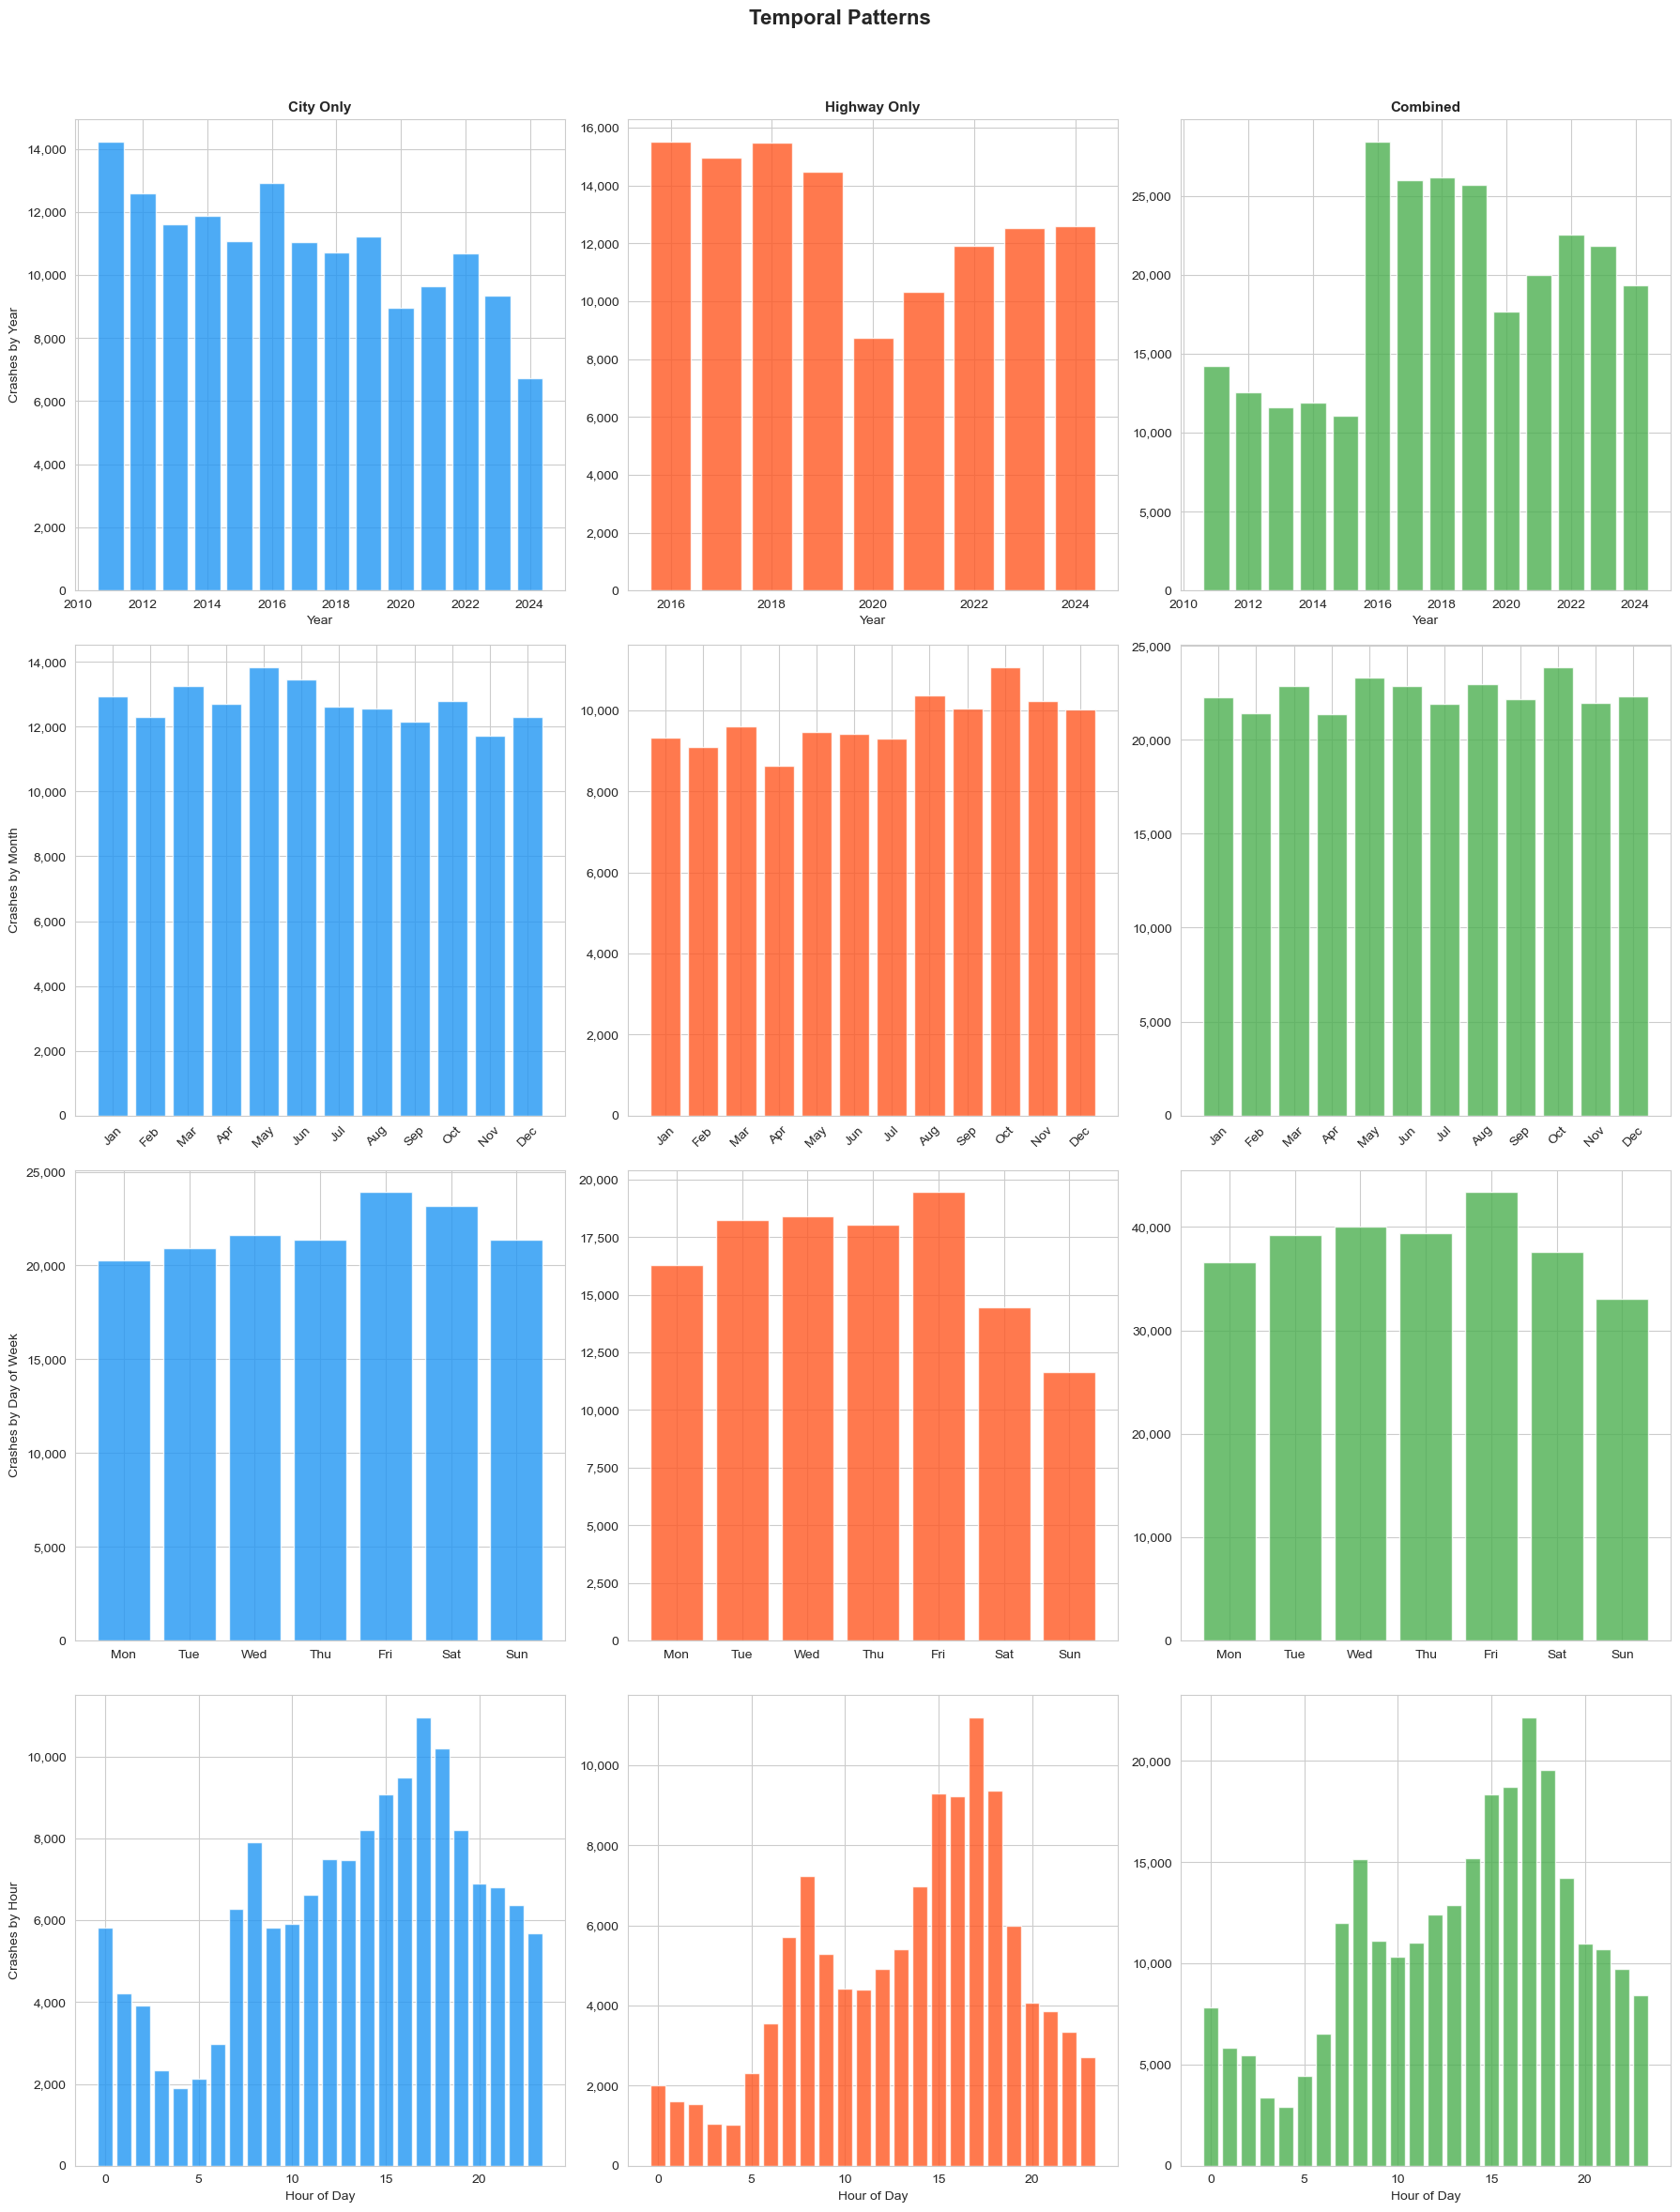

Saved: temporal_patterns.png


In [4]:
fig, axes = plt.subplots(4, 3, figsize=(18, 24))
fig.suptitle('Temporal Patterns', fontsize=16, fontweight='bold')

day_names   = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

for col, (name, df, color) in enumerate(zip(DATASETS, dfs, COLORS)):
    ax = axes[0, col]
    yr = df['crash_year'].value_counts().sort_index()
    ax.bar(yr.index.astype(int), yr.values, color=color, alpha=0.8)
    ax.set_title(f'{name}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Year')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    if col == 0: ax.set_ylabel('Crashes by Year')

    ax = axes[1, col]
    mo = df['crash_month'].value_counts().sort_index()
    ax.bar(mo.index.astype(int), mo.values, color=color, alpha=0.8)
    ax.set_xticks(range(1,13)); ax.set_xticklabels(month_names, rotation=45)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    if col == 0: ax.set_ylabel('Crashes by Month')

    ax = axes[2, col]
    dow = df['crash_dayofweek'].value_counts().sort_index()
    ax.bar(range(len(dow)), dow.values, color=color, alpha=0.8)
    ax.set_xticks(range(len(day_names))); ax.set_xticklabels(day_names)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    if col == 0: ax.set_ylabel('Crashes by Day of Week')

    ax = axes[3, col]
    hr = df['crash_hour'].value_counts().sort_index()
    ax.bar(hr.index.astype(int), hr.values, color=color, alpha=0.8)
    ax.set_xlabel('Hour of Day')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    if col == 0: ax.set_ylabel('Crashes by Hour')

plt.tight_layout(rect=[0, 0, 1, 0.96])
save_fig('temporal_patterns')

## 3. Severity by Time

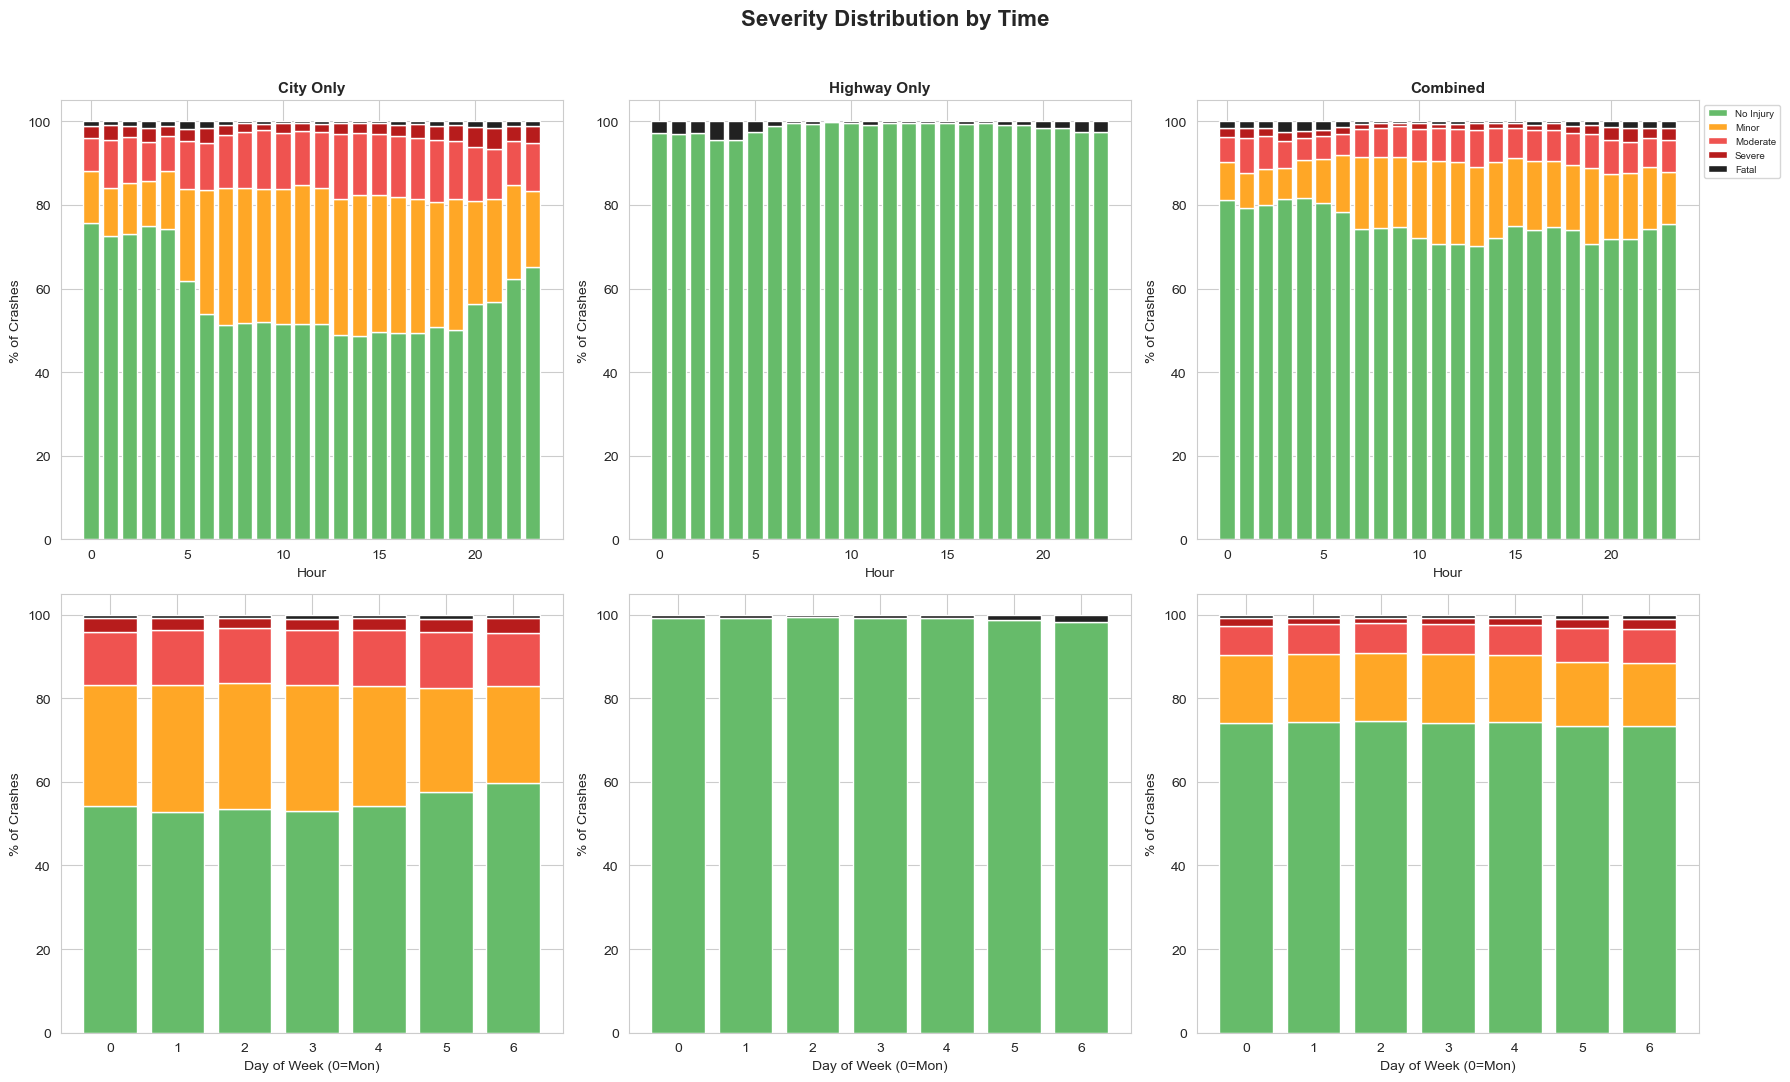

Saved: severity_temporal.png


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Severity Distribution by Time', fontsize=16, fontweight='bold')

for col, (name, df) in enumerate(zip(DATASETS, dfs)):
    ax = axes[0, col]
    pivot = df.groupby(['crash_hour', 'injury_severity']).size().unstack(fill_value=0)
    pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
    sev_present = [s for s in sorted(pivot_pct.columns) if s in SEV_LABELS]
    bottom = np.zeros(len(pivot_pct))
    for sev in sev_present:
        color = SEV_COLORS[int(sev)]
        ax.bar(pivot_pct.index, pivot_pct[sev], bottom=bottom,
               color=color, label=SEV_LABELS.get(int(sev), str(sev)), width=0.8)
        bottom += pivot_pct[sev].values
    ax.set_title(f'{name}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Hour'); ax.set_ylabel('% of Crashes')
    if col == 2: ax.legend(loc='upper left', fontsize=7, bbox_to_anchor=(1, 1))

    ax = axes[1, col]
    pivot = df.groupby(['crash_dayofweek', 'injury_severity']).size().unstack(fill_value=0)
    pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
    bottom = np.zeros(len(pivot_pct))
    for sev in sev_present:
        if sev in pivot_pct.columns:
            color = SEV_COLORS[int(sev)]
            ax.bar(pivot_pct.index, pivot_pct[sev], bottom=bottom,
                   color=color, label=SEV_LABELS.get(int(sev), str(sev)), width=0.8)
            bottom += pivot_pct[sev].values
    ax.set_xlabel('Day of Week (0=Mon)')
    ax.set_ylabel('% of Crashes')

plt.tight_layout(rect=[0, 0, 1, 0.96])
save_fig('severity_temporal')

## 4. Environmental Conditions

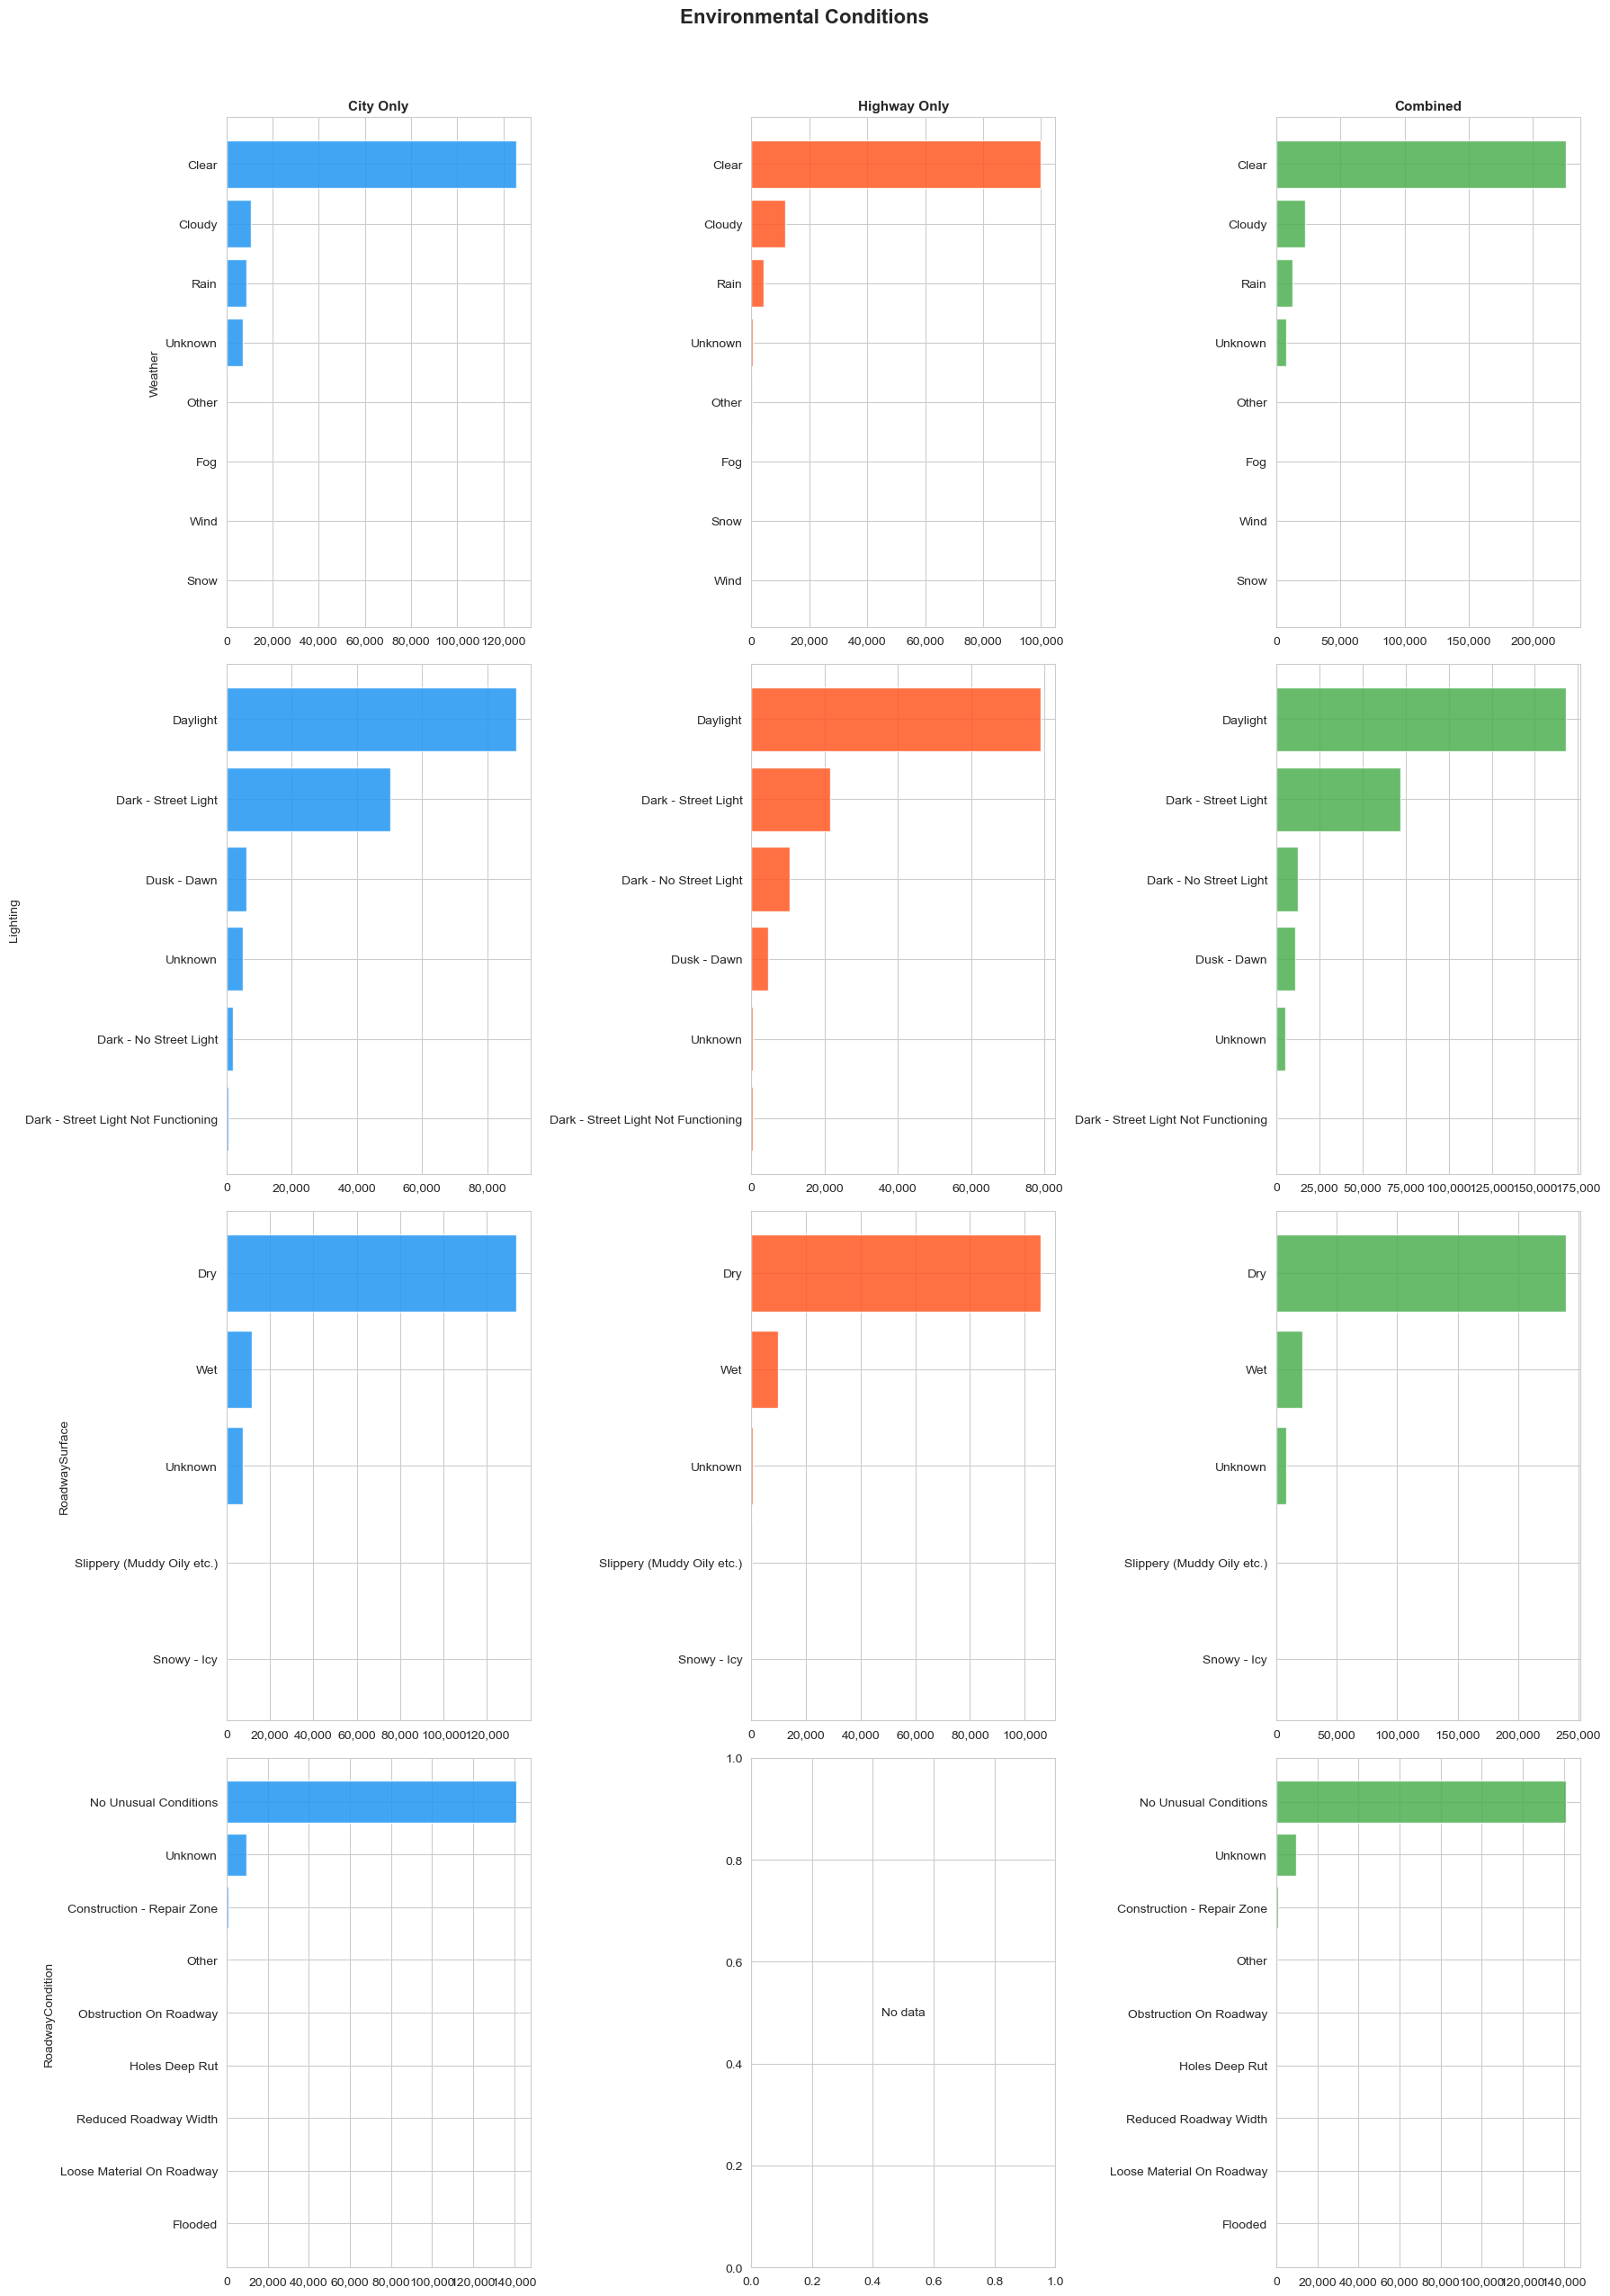

Saved: environmental_conditions.png


In [6]:
env_cols = ['Weather', 'Lighting', 'RoadwaySurface', 'RoadwayCondition']

fig, axes = plt.subplots(4, 3, figsize=(18, 26))
fig.suptitle('Environmental Conditions', fontsize=16, fontweight='bold')

for row, col_name in enumerate(env_cols):
    for col, (name, df, color) in enumerate(zip(DATASETS, dfs, COLORS)):
        ax = axes[row, col]
        if col_name not in df.columns or df[col_name].isna().all():
            ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
            if row == 0: ax.set_title(f'{name}')
            continue
        counts = df[col_name].value_counts().head(10)
        ax.barh(counts.index[::-1], counts.values[::-1], color=color, alpha=0.85)
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
        if row == 0: ax.set_title(f'{name}', fontsize=11, fontweight='bold')
        if col == 0: ax.set_ylabel(col_name, fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.96])
save_fig('environmental_conditions')

## 5. Collision Characteristics

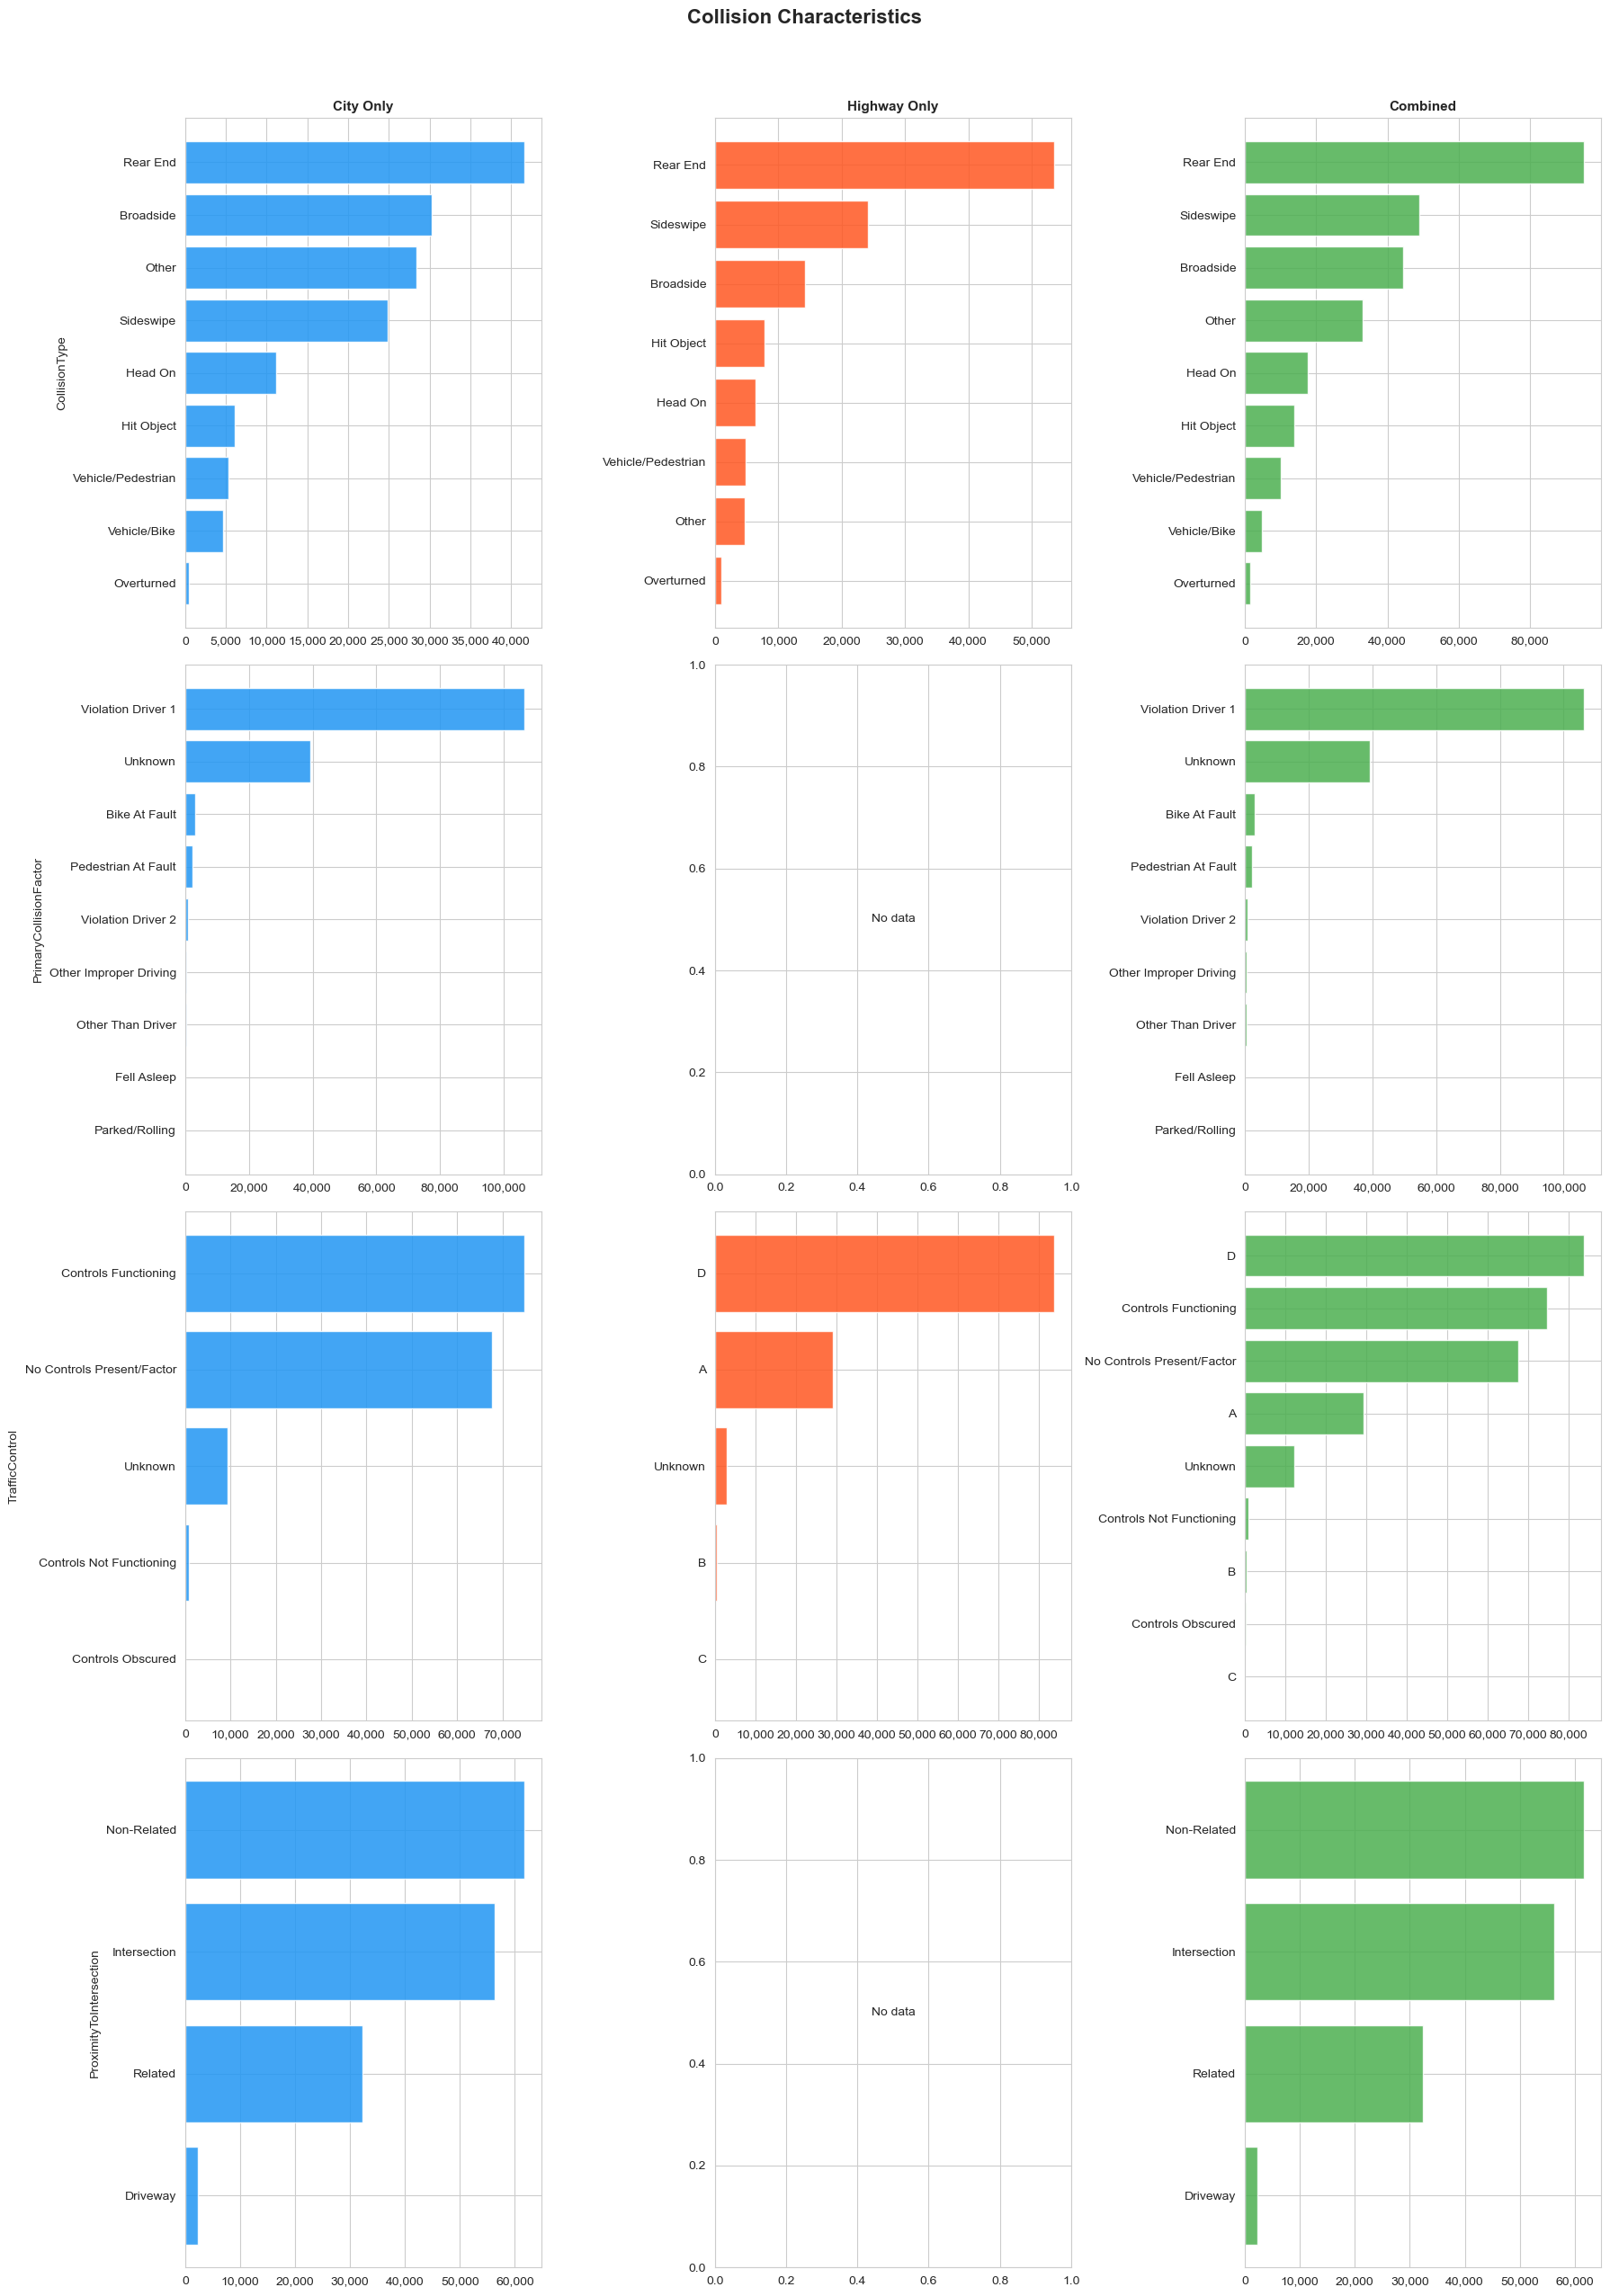

Saved: collision_characteristics.png


In [7]:
coll_cols = ['CollisionType', 'PrimaryCollisionFactor', 'TrafficControl', 'ProximityToIntersection']

fig, axes = plt.subplots(4, 3, figsize=(18, 26))
fig.suptitle('Collision Characteristics', fontsize=16, fontweight='bold')

for row, col_name in enumerate(coll_cols):
    for col, (name, df, color) in enumerate(zip(DATASETS, dfs, COLORS)):
        ax = axes[row, col]
        if col_name not in df.columns or df[col_name].isna().all():
            ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
            if row == 0: ax.set_title(f'{name}')
            continue
        counts = df[col_name].value_counts().head(10)
        ax.barh(counts.index[::-1], counts.values[::-1], color=color, alpha=0.85)
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
        if row == 0: ax.set_title(f'{name}', fontsize=11, fontweight='bold')
        if col == 0: ax.set_ylabel(col_name, fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.96])
save_fig('collision_characteristics')

## 6. Vehicle & Driver Characteristics

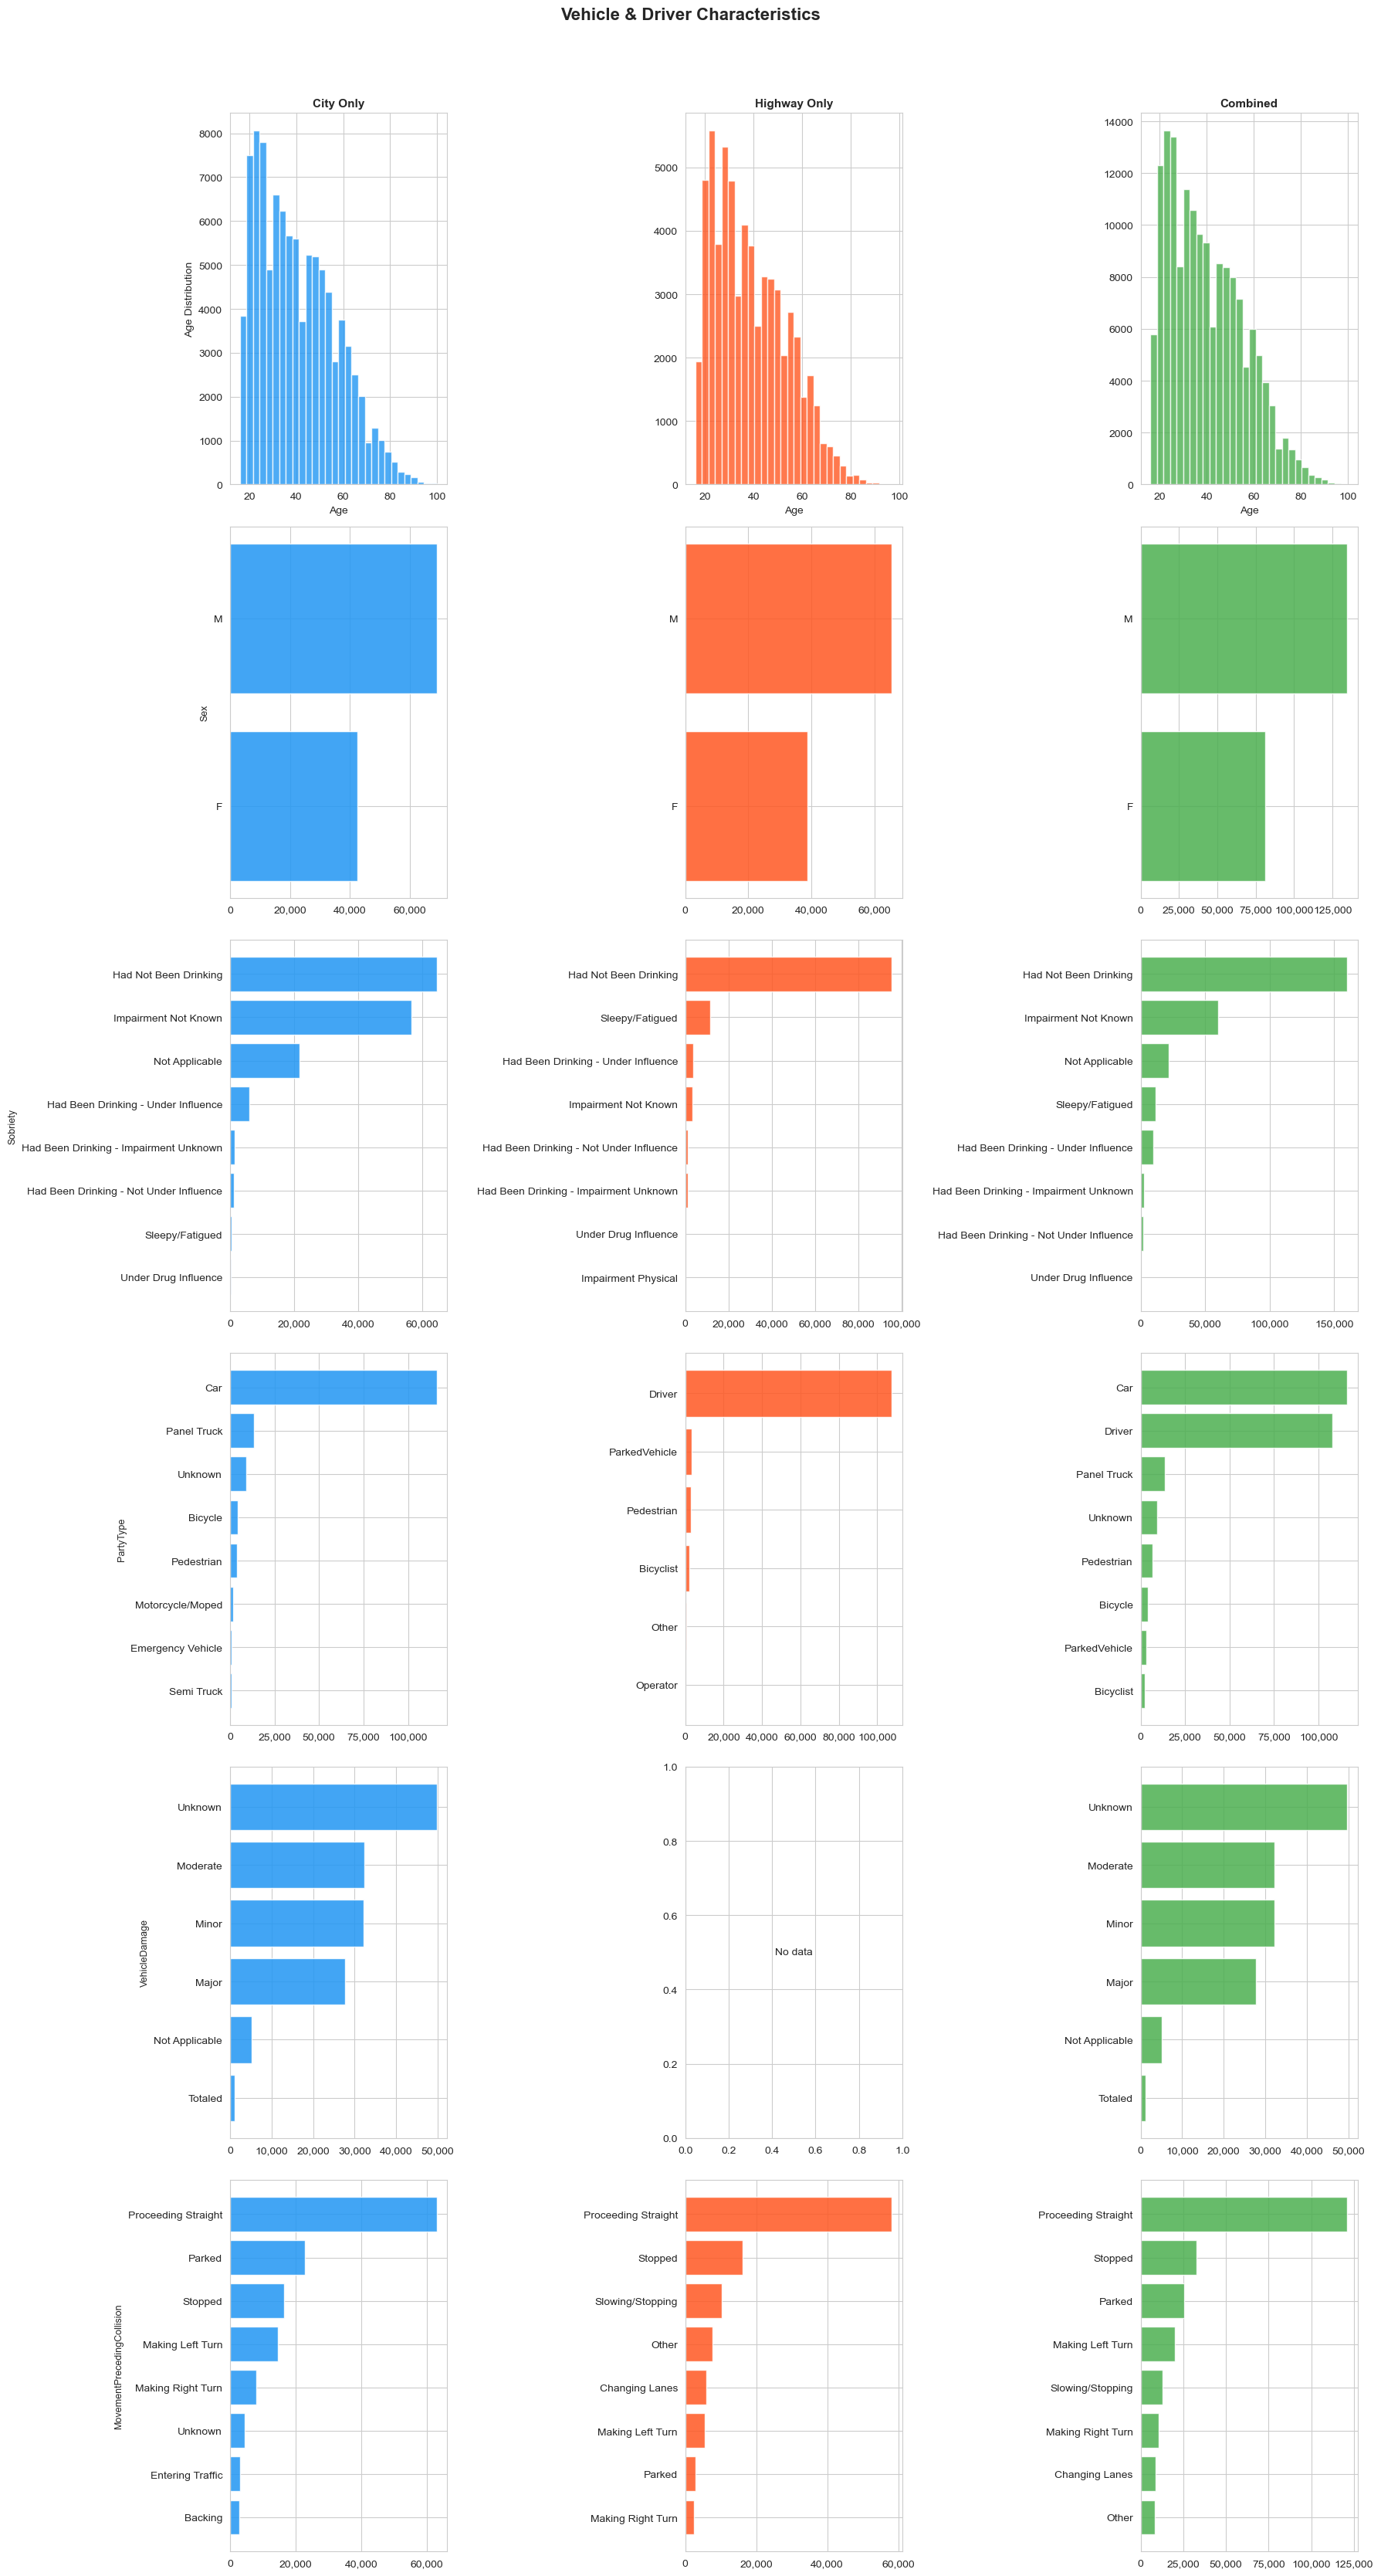

Saved: vehicle_driver_characteristics.png


In [8]:
fig, axes = plt.subplots(6, 3, figsize=(18, 34))
fig.suptitle('Vehicle & Driver Characteristics', fontsize=16, fontweight='bold')

cat_cols = ['Sex', 'Sobriety', 'PartyType', 'VehicleDamage', 'MovementPrecedingCollision']

for col, (name, df, color) in enumerate(zip(DATASETS, dfs, COLORS)):
    ax = axes[0, col]
    age_data = df['Age'].dropna()
    age_data = age_data[(age_data >= 16) & (age_data <= 100)]
    ax.hist(age_data, bins=30, color=color, alpha=0.8, edgecolor='white')
    ax.set_title(f'{name}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Age')
    if col == 0: ax.set_ylabel('Age Distribution')

    for row, cat in enumerate(cat_cols, start=1):
        ax = axes[row, col]
        if cat not in df.columns or df[cat].isna().all():
            ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
            continue
        counts = df[cat].value_counts().head(8)
        ax.barh(counts.index[::-1], counts.values[::-1], color=color, alpha=0.85)
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
        if col == 0: ax.set_ylabel(cat, fontsize=9)

plt.tight_layout(rect=[0, 0, 1, 0.96])
save_fig('vehicle_driver_characteristics')

## 7–10. Severity by Key Features

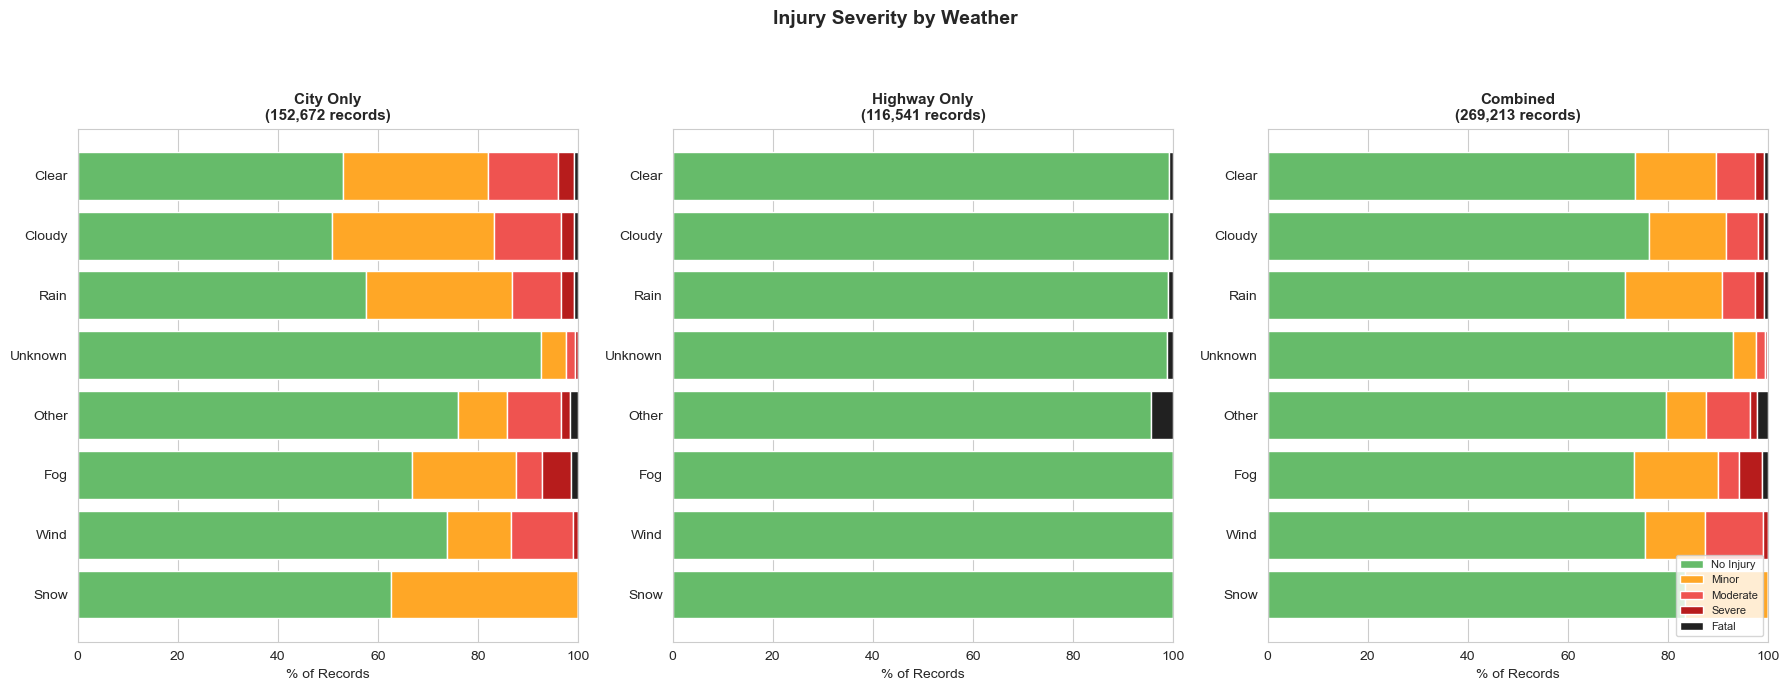

Saved: severity_by_weather.png


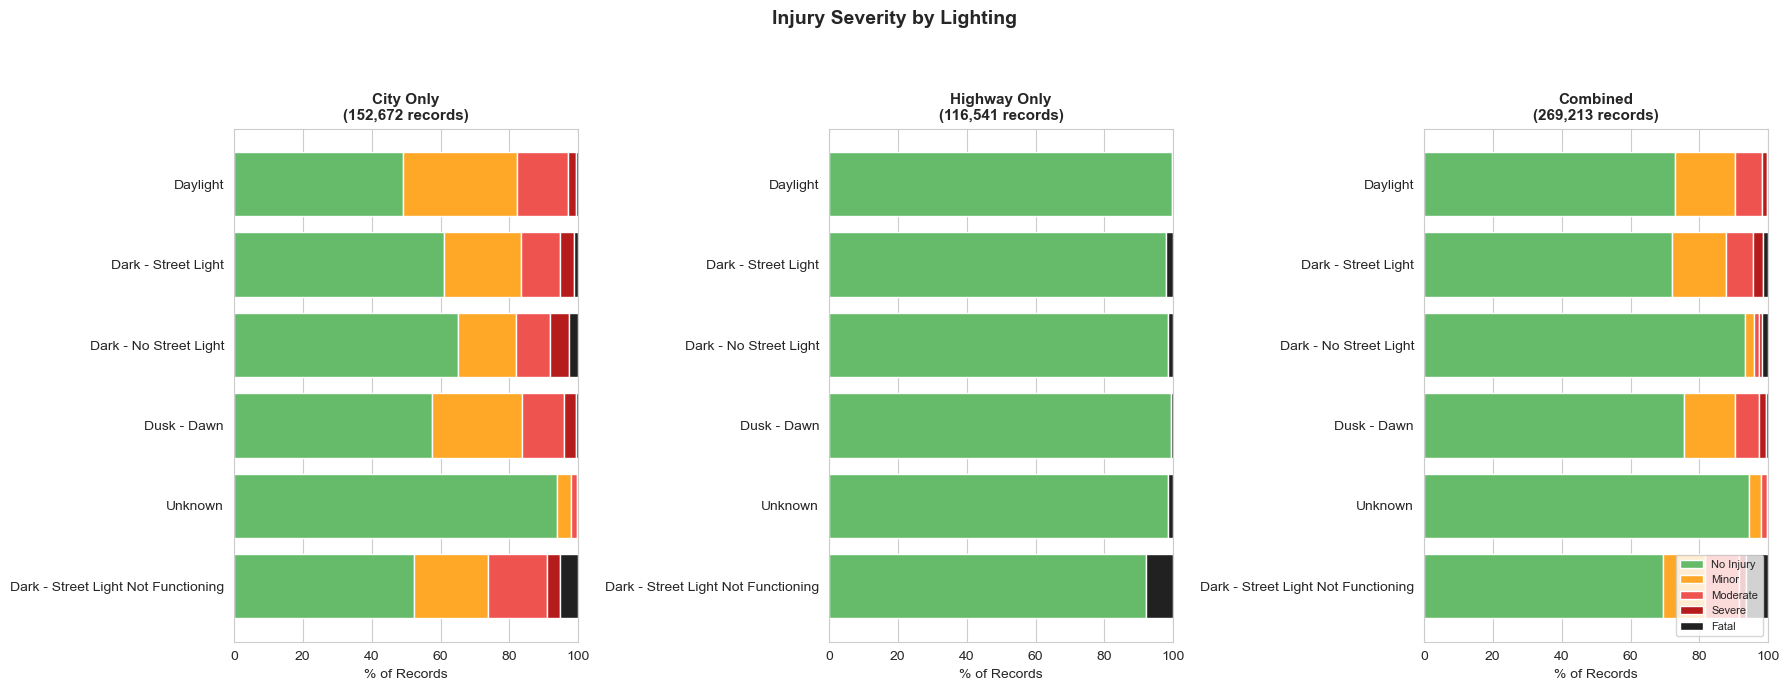

Saved: severity_by_lighting.png


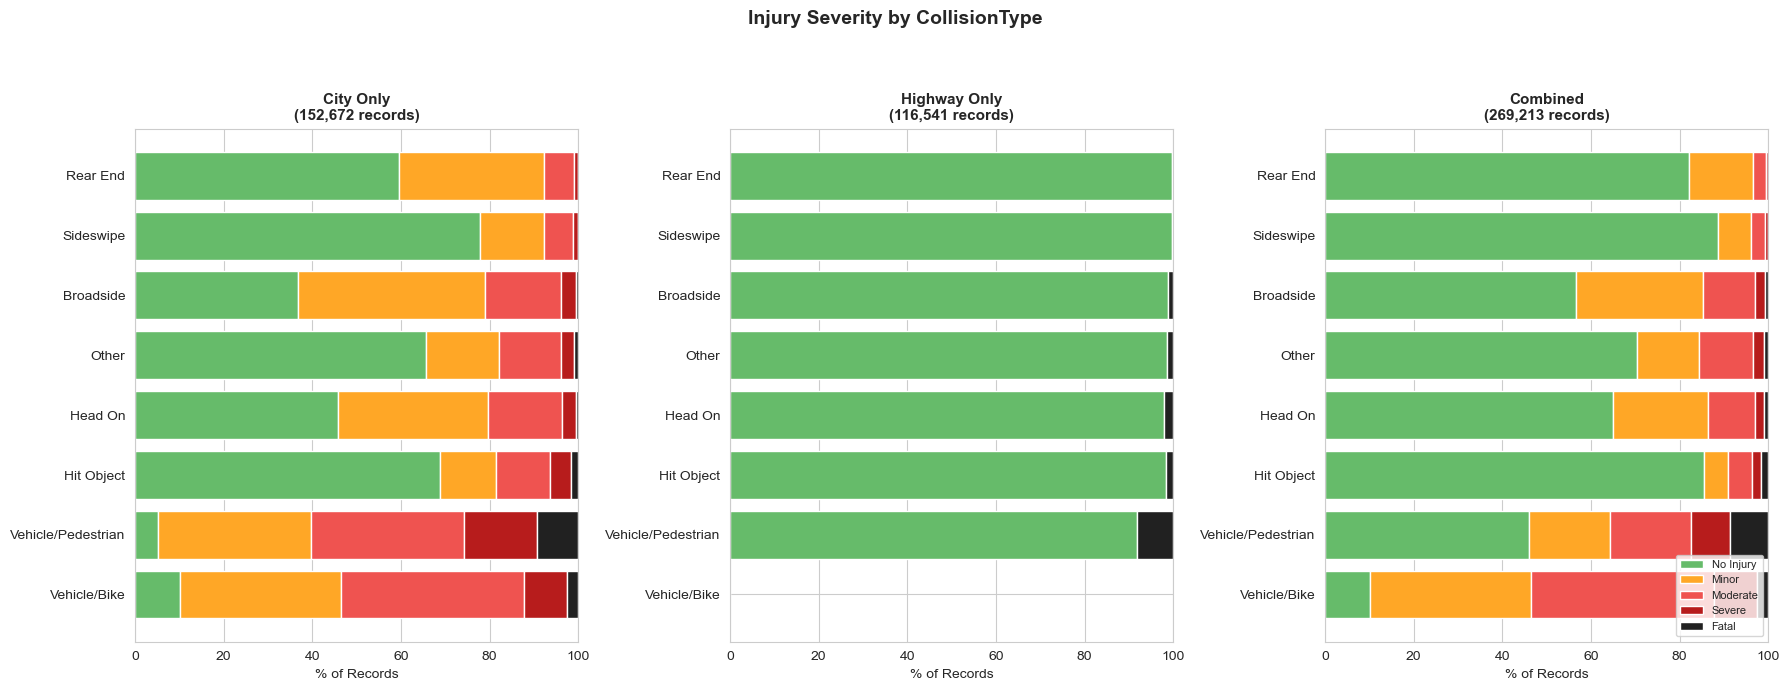

Saved: severity_by_collisiontype.png


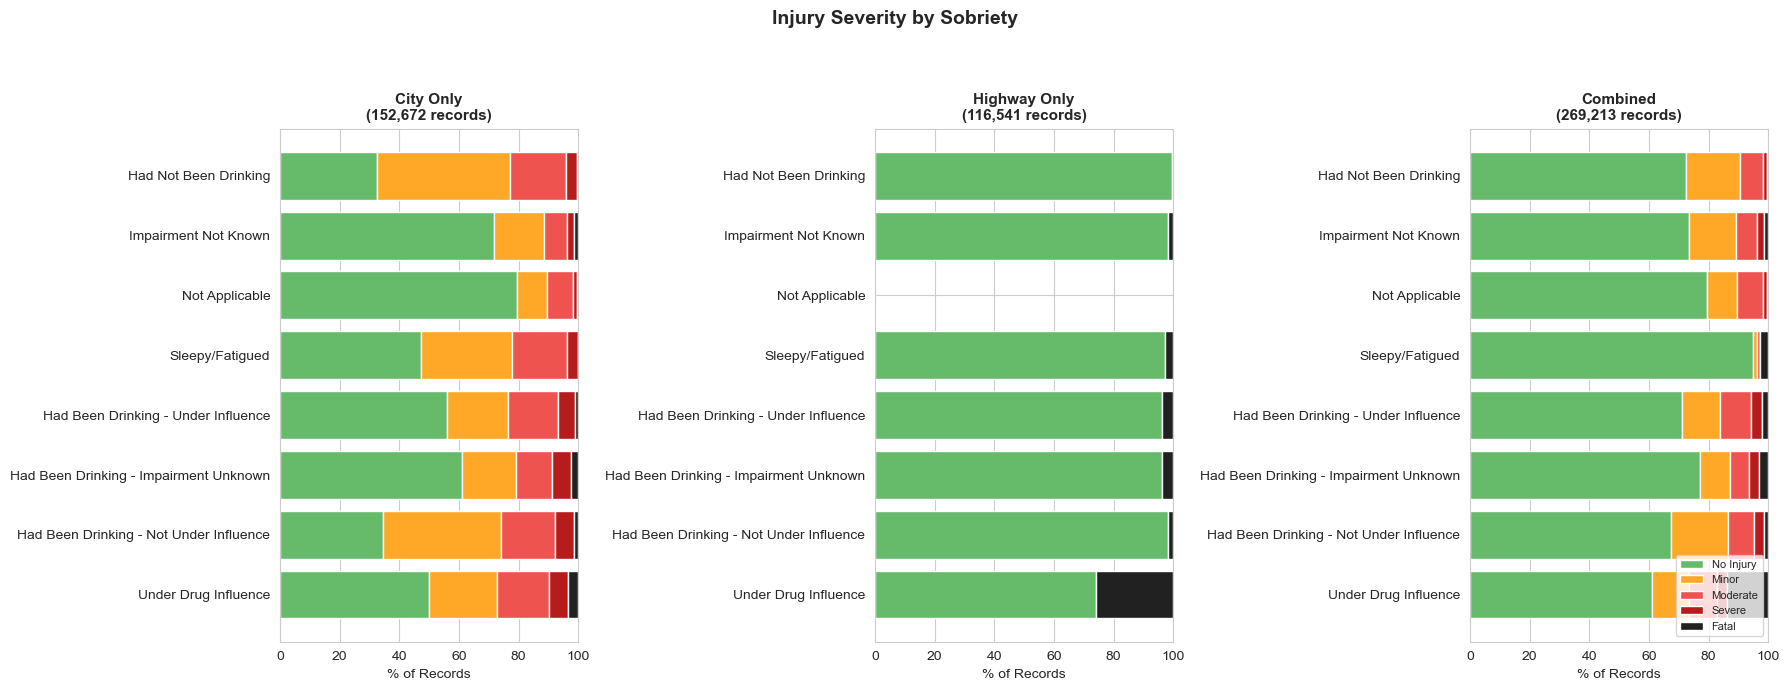

Saved: severity_by_sobriety.png


In [9]:
def plot_severity_by_feature(feature, fig_name, top_n=8):
    fig, axes = plt.subplots(1, 3, figsize=(18, 7))
    fig.suptitle(f'Injury Severity by {feature}', fontsize=14, fontweight='bold')

    shared_cats = (df_combined[feature].value_counts().head(top_n).index.tolist()
                   if feature in df_combined.columns else [])

    for col, (name, df) in enumerate(zip(DATASETS, dfs)):
        ax = axes[col]
        if feature not in df.columns or df[feature].isna().all() or not shared_cats:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
            ax.set_title(name)
            continue

        sub = df[df[feature].isin(shared_cats)]
        pivot = sub.groupby([feature, 'injury_severity']).size().unstack(fill_value=0)
        pivot = pivot.reindex(shared_cats, fill_value=0)
        pivot_pct = pivot.div(pivot.sum(axis=1).replace(0, np.nan), axis=0).fillna(0) * 100
        pivot_pct = pivot_pct.iloc[::-1]

        all_sev = sorted(pivot_pct.columns)
        bottom = np.zeros(len(pivot_pct))
        for sev in all_sev:
            color = SEV_COLORS[int(sev)] if int(sev) < len(SEV_COLORS) else '#999999'
            ax.barh(pivot_pct.index, pivot_pct[sev], left=bottom,
                    color=color, label=SEV_LABELS.get(int(sev), str(sev)))
            bottom += pivot_pct[sev].values
        ax.set_xlim(0, 100)
        ax.set_xlabel('% of Records')
        ax.set_title(f'{name}\n({len(df):,} records)', fontsize=11, fontweight='bold')
        if col == 2:
            ax.legend(loc='lower right', fontsize=8)

    plt.tight_layout(rect=[0, 0, 1, 0.93])
    save_fig(fig_name)

plot_severity_by_feature('Weather',       'severity_by_weather')
plot_severity_by_feature('Lighting',      'severity_by_lighting')
plot_severity_by_feature('CollisionType', 'severity_by_collisiontype')
plot_severity_by_feature('Sobriety',      'severity_by_sobriety')

## 11. Feature Associations with Severity (Cramér's V)

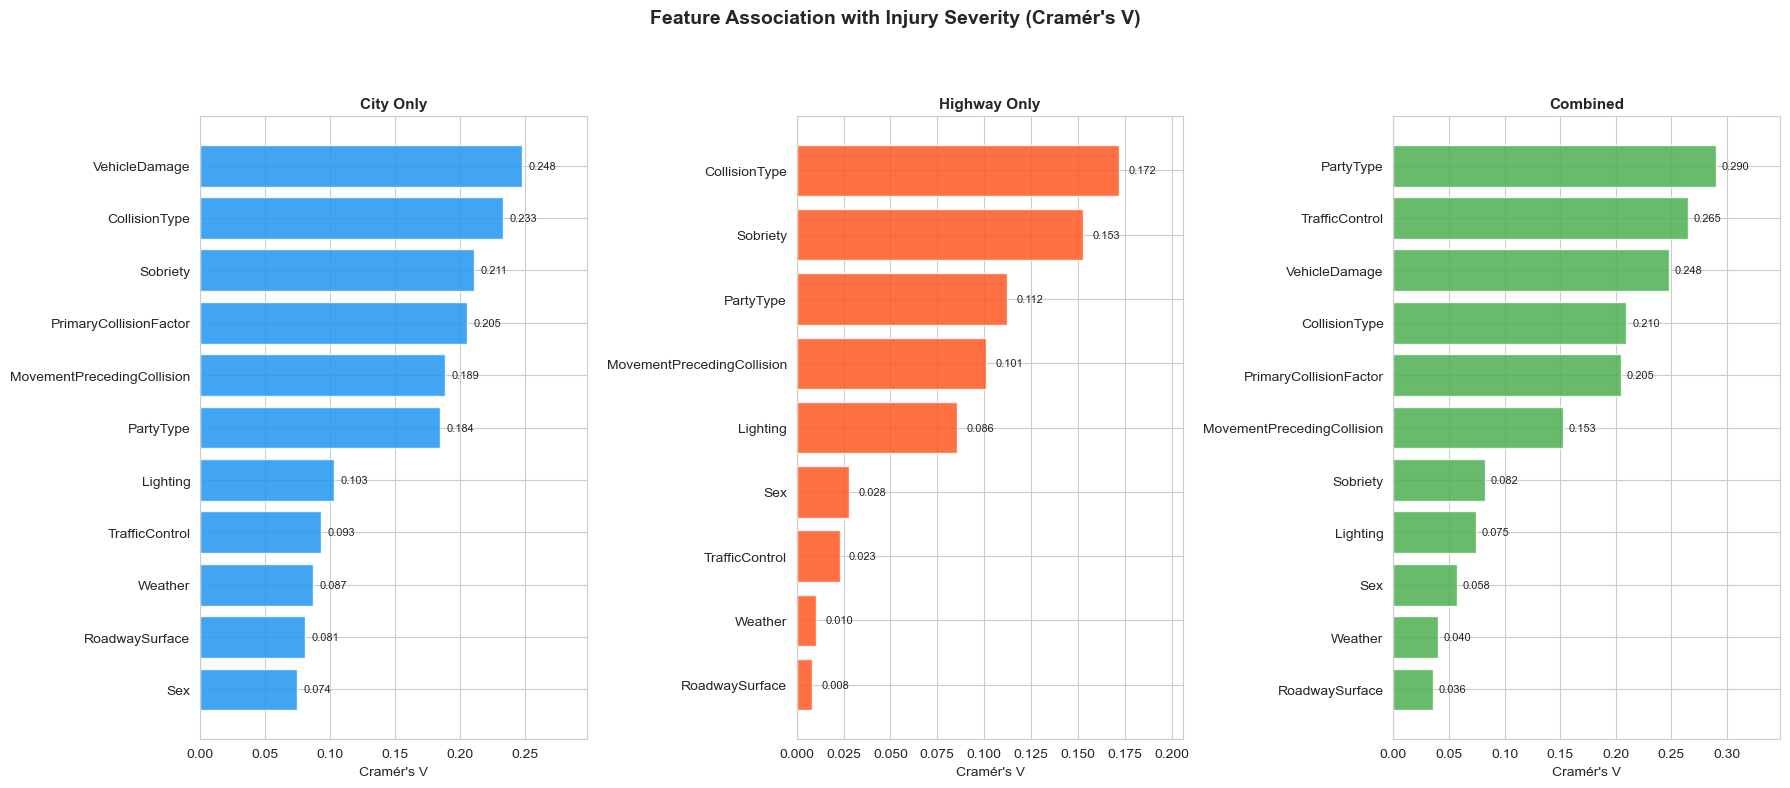

Saved: feature_associations.png


In [10]:
def cramers_v(x, y):
    """Calculate Cramér's V statistic for categorical-categorical association."""
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    min_dim = min(confusion_matrix.shape) - 1
    if min_dim == 0:
        return 0.0
    return np.sqrt(chi2 / (n * min_dim))

cat_features = [
    'CollisionType', 'PrimaryCollisionFactor', 'Sobriety', 'Lighting',
    'Weather', 'RoadwaySurface', 'TrafficControl', 'MovementPrecedingCollision',
    'PartyType', 'Sex', 'VehicleDamage'
]

fig, axes = plt.subplots(1, 3, figsize=(18, 8))
fig.suptitle("Feature Association with Injury Severity (Cramér's V)", fontsize=14, fontweight='bold')

for col, (name, df, color) in enumerate(zip(DATASETS, dfs, COLORS)):
    ax = axes[col]
    results = {}
    for feat in cat_features:
        if feat not in df.columns:
            continue
        if df[feat].isna().mean() > 0.8:
            continue
        valid = df[[feat, 'injury_severity']].dropna()
        if len(valid) < 100:
            continue
        try:
            results[feat] = cramers_v(valid[feat], valid['injury_severity'])
        except Exception:
            pass

    if not results:
        ax.text(0.5, 0.5, 'Insufficient data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(name)
        continue

    s = pd.Series(results).sort_values()
    ax.barh(s.index, s.values, color=color, alpha=0.85)
    ax.set_xlim(0, max(s.values) * 1.2)
    ax.set_xlabel("Cramér's V")
    ax.set_title(f'{name}', fontsize=11, fontweight='bold')
    for i, (feat, val) in enumerate(s.items()):
        ax.text(val + 0.005, i, f'{val:.3f}', va='center', fontsize=8)

plt.tight_layout(rect=[0, 0, 1, 0.93])
save_fig('feature_associations')

## 12. Numeric Feature Correlation with Severity

> **Note on Highway Age correlation ≈ 0.00**: This is a mathematical consequence of the binary severity limitation. For highway records, `injury_severity` is almost always `0` (99.1% of cases) with only a tiny fraction being `4`. When one variable has almost no variance, Pearson correlation with any other variable collapses toward zero — it does not mean Age is unimportant on highways. The relationship simply cannot be detected with a near-constant target variable. This will be revisited if per-party injury severity becomes available for highway records.

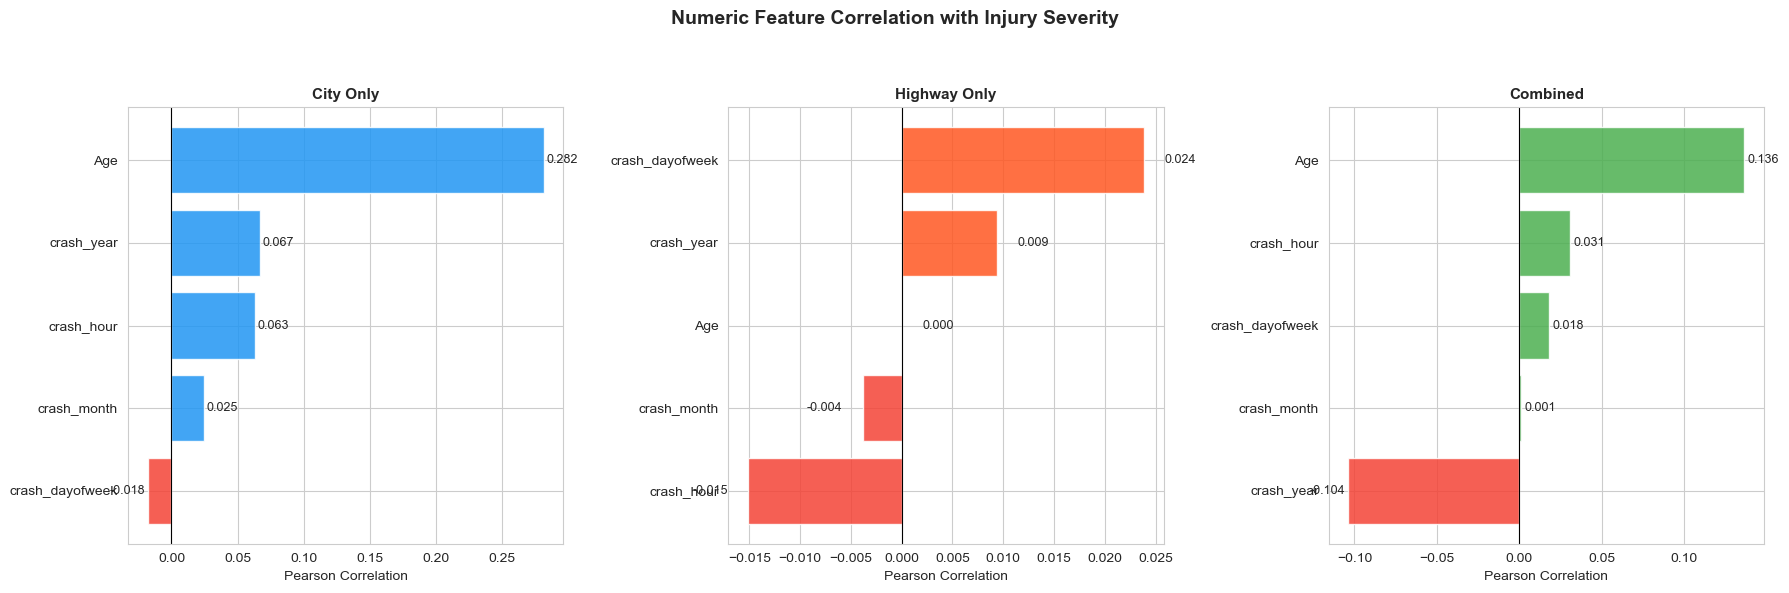

Saved: correlation_severity.png


In [11]:
num_features = ['crash_year', 'crash_month', 'crash_hour', 'crash_dayofweek', 'Age']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Numeric Feature Correlation with Injury Severity', fontsize=14, fontweight='bold')

for col, (name, df, color) in enumerate(zip(DATASETS, dfs, COLORS)):
    ax = axes[col]
    corrs = {}
    for feat in num_features:
        if feat not in df.columns:
            continue
        valid = df[[feat, 'injury_severity']].dropna()
        if len(valid) < 100:
            continue
        corrs[feat] = valid[feat].corr(valid['injury_severity'])

    if not corrs:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        continue

    s = pd.Series(corrs).sort_values()
    bar_colors = [color if v >= 0 else '#F44336' for v in s.values]
    ax.barh(s.index, s.values, color=bar_colors, alpha=0.85)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Pearson Correlation')
    ax.set_title(f'{name}', fontsize=11, fontweight='bold')
    for i, (feat, val) in enumerate(s.items()):
        offset = 0.002 if val >= 0 else -0.002
        ax.text(val + offset, i, f'{val:.3f}', va='center', fontsize=9,
                ha='left' if val >= 0 else 'right')

plt.tight_layout(rect=[0, 0, 1, 0.93])
save_fig('correlation_severity')

## 13. Missing Values

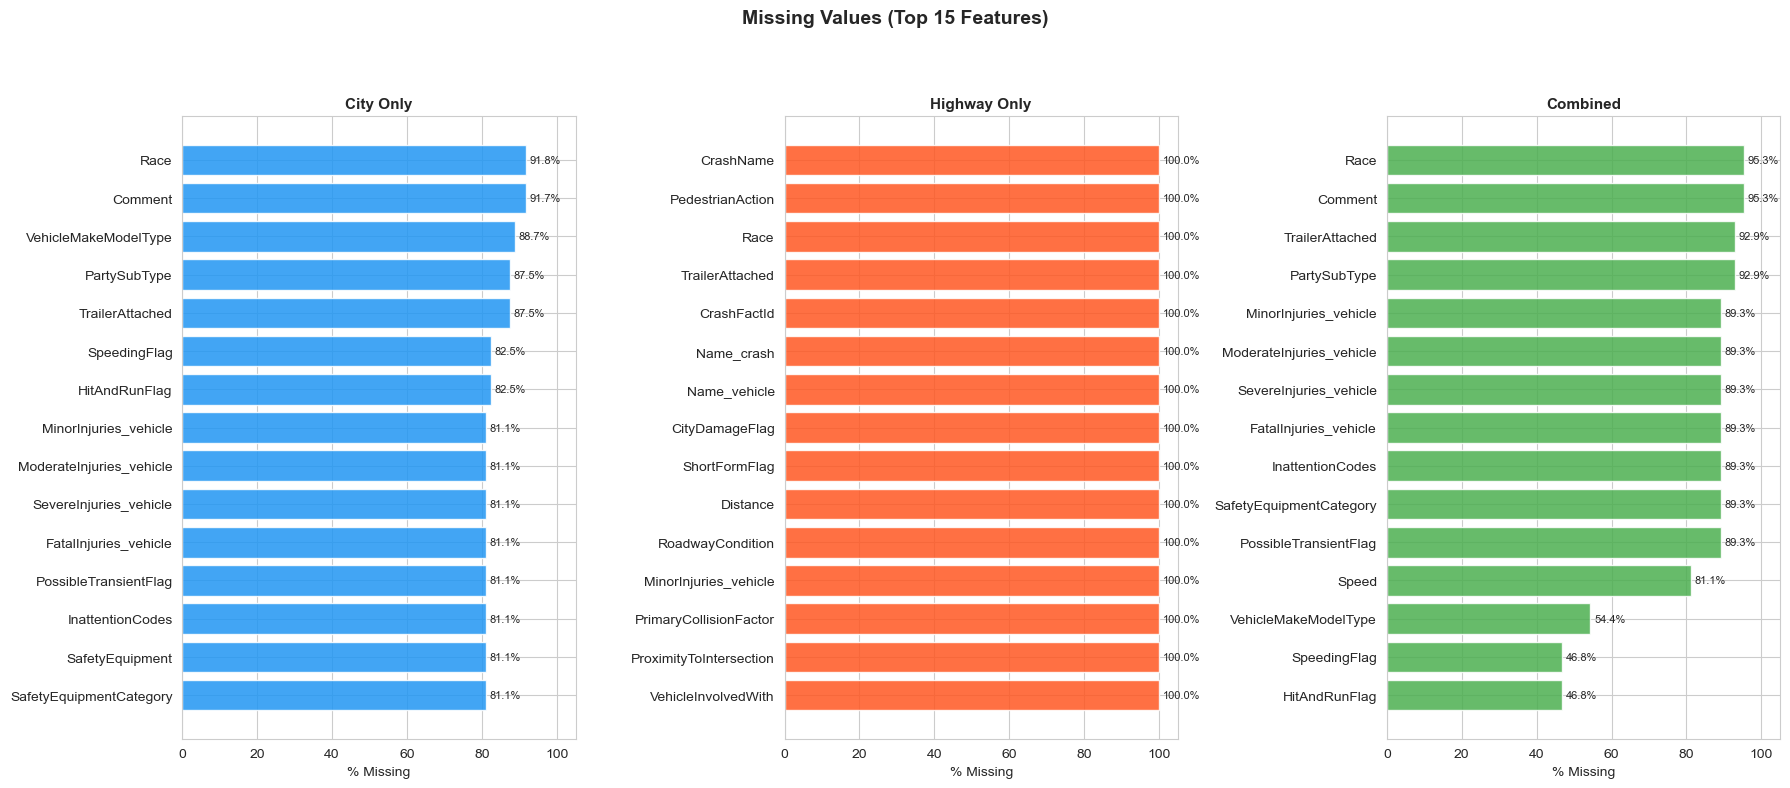

Saved: missing_values.png


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 8))
fig.suptitle('Missing Values (Top 15 Features)', fontsize=14, fontweight='bold')

for col, (name, df, color) in enumerate(zip(DATASETS, dfs, COLORS)):
    ax = axes[col]
    display_df = df[[c for c in df.columns if not c.startswith('_')]]
    missing_pct = (display_df.isna().mean() * 100).sort_values(ascending=False).head(15)
    missing_pct = missing_pct[missing_pct > 0]

    if missing_pct.empty:
        ax.text(0.5, 0.5, 'No missing values', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(name)
        continue

    ax.barh(missing_pct.index[::-1], missing_pct.values[::-1], color=color, alpha=0.85)
    ax.set_xlim(0, 105)
    ax.set_xlabel('% Missing')
    ax.set_title(f'{name}', fontsize=11, fontweight='bold')
    for i, (feat, val) in enumerate(missing_pct[::-1].items()):
        ax.text(val + 1, i, f'{val:.1f}%', va='center', fontsize=8)

plt.tight_layout(rect=[0, 0, 1, 0.93])
save_fig('missing_values')

## Summary

All 13 comparative figures saved to `reports/figures/comparative/`.

| Figure | File |
|--------|------|
| Severity Distribution | `target_distribution.png` |
| Temporal Patterns | `temporal_patterns.png` |
| Severity by Time | `severity_temporal.png` |
| Environmental Conditions | `environmental_conditions.png` |
| Collision Characteristics | `collision_characteristics.png` |
| Vehicle & Driver | `vehicle_driver_characteristics.png` |
| Severity by Weather | `severity_by_weather.png` |
| Severity by Lighting | `severity_by_lighting.png` |
| Severity by Collision Type | `severity_by_collisiontype.png` |
| Severity by Sobriety | `severity_by_sobriety.png` |
| Feature Associations (Cramér's V) | `feature_associations.png` |
| Numeric Correlation | `correlation_severity.png` |
| Missing Values | `missing_values.png` |

**Key observations to highlight in the technical report:**
- Highway crashes skew toward "No Injury" due to the severity limitation noted above
- Highway temporal patterns differ from city (e.g., fewer pedestrian-involved crashes)
- Combined dataset amplifies class imbalance — SMOTE/class weights remain essential for modeling